# Data Dummies
<div dir='rtl'>
    <p>فى هذا الدرس سوف تواجهنا مشكله مع تعليم الأله وهى النصوص</p>
    <p>الأله لا تفهم النصوص بل تفهم الارقام فقط، لذالك نحتاج الى تحويل النصوص الى ارقام، مثلاً يمكن ان نحولها الى <code>boolean</code> للسهوله</p>
    <p>فى هذا الدرس سوف نتعلم كيفية عمل لذالك فى بيانات شركة We مثلاً</p>
    <p>
        نريد توقع إذا كان العميل هايلغى اشتراكه وام لا
        <a href='https://www.kaggle.com/datasets/blastchar/telco-customer-churn' target='_blank'>لينك الملف</a>
    </p>
</div>

In [205]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Data Cleaning
<p dir='rtl'>دائماً قبل وضع انواع بيانات مناسبه، يجب التأكد انه لا يوجد بيانات مفقوده</p>

In [206]:
df = pd.read_csv(
    "Telco-Customer-Churn.csv",
    true_values=["Yes"],
    false_values=["No"],
    dtype={
        "SeniorCitizen": np.bool_,
        "tenure": np.int8,
        "MonthlyCharges": np.float32
    }
)
df.drop(columns=["customerID"], inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.850000,29.85,False
1,Male,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,56.950001,1889.5,False
2,Male,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,53.849998,108.15,True
3,Male,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,Female,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,70.699997,151.65,True


In [207]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   bool   
 2   Partner           7043 non-null   bool   
 3   Dependents        7043 non-null   bool   
 4   tenure            7043 non-null   int8   
 5   PhoneService      7043 non-null   bool   
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   bool   
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

<div dir='rtl'>
    <p>سوف تلاحظ ان لا يوجد لدينا بيانات فارغه ولكل لدينا مسافات فارغه</p>
</div>

In [208]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [209]:
df[df['TotalCharges'] == " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,False,True,True,0,False,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,True,Bank transfer (automatic),52.549999,,False
753,Male,False,False,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.250000,,False
936,Female,False,True,True,0,True,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,False,Mailed check,80.849998,,False
1082,Male,False,True,True,0,True,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.750000,,False
1340,Female,False,True,True,0,False,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,False,Credit card (automatic),56.049999,,False
3331,Male,False,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,19.850000,,False
3826,Male,False,True,True,0,True,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.350000,,False
4380,Female,False,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.000000,,False
5218,Male,False,True,True,0,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,True,Mailed check,19.700001,,False
6670,Female,False,True,True,0,True,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,False,Mailed check,73.349998,,False


<p dir='rtl'>الأن يمكننا ان ننظف البيانات ونكتب انواع البيانات لسهولة العمليات الحسابيه وتوفير المساحه</p>

In [210]:
df['TotalCharges'] = np.where(df['TotalCharges'] == " ", 0.0, df['TotalCharges'])
df['TotalCharges'] = df['TotalCharges'].astype(np.float32)

<p dir='rtl'>بعد ان قمنا بتنظيف البيانات الان نريد تحويل النصوص الى <code>boolean</code></p>

In [211]:
df = pd.get_dummies(df, columns=["gender", "MultipleLines", "InternetService", "OnlineSecurity" ,"OnlineBackup" ,"DeviceProtection" ,"TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"])

In [212]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,False,True,False,1,False,True,29.850000,29.850000,False,True,False,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
1,False,False,False,34,True,False,56.950001,1889.500000,False,False,True,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True
2,False,False,False,2,True,True,53.849998,108.150002,True,False,True,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
3,False,False,False,45,False,False,42.299999,1840.750000,False,False,True,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,True,False,True,False,False,False
4,False,False,False,2,True,True,70.699997,151.649994,True,True,False,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False


In [213]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   bool   
 1   Partner                                  7043 non-null   bool   
 2   Dependents                               7043 non-null   bool   
 3   tenure                                   7043 non-null   int8   
 4   PhoneService                             7043 non-null   bool   
 5   PaperlessBilling                         7043 non-null   bool   
 6   MonthlyCharges                           7043 non-null   float32
 7   TotalCharges                             7043 non-null   float32
 8   Churn                                    7043 non-null   bool   
 9   gender_Female                            7043 non-null   bool   
 10  gender_Male                              7043 non-null   bo

## Prepare the data

In [214]:
X = df.drop(columns=["Churn"])
Y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=2942)

## train the model

In [215]:
model = LogisticRegression(max_iter=4000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [216]:
round(model.score(x_test, y_test) * 100, 2)

83.25

## testing

In [217]:
prediction = model.predict(x_test)
print(f"Correct: {x_test[y_test == prediction].shape[0]} ✅")
print(f"Not Correct: {x_test[y_test != prediction].shape[0]} ❌")

Correct: 1173 ✅
Not Correct: 236 ❌


## Visualizing

[[952  90]
 [146 221]]


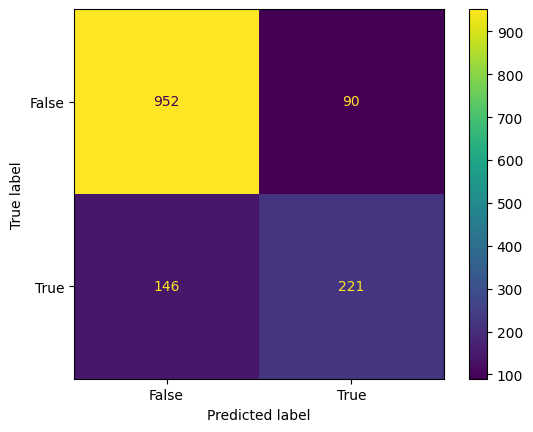

In [218]:
cm = confusion_matrix(y_test, prediction)
print(cm)

disp = ConfusionMatrixDisplay(cm, display_labels=['False', 'True'])
disp.plot()
plt.show()